### Loading dataset, Scaling data points and splitting data
###### Replicating the study (DOI: 10.1109/ACCESS.2023.3280122), where only 6 features were used

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df = pd.read_csv("CICIDS2017_Wednesday_Paper.csv")
df.columns=df.columns.str.strip()

#using the selected features
selectedFeatures=['Destination Port', 'Total Length of Bwd Packets','Bwd Packet Length Std', 'Flow IAT Mean', 'Bwd Packets/s','Packet Length Mean', 'Label']
df=df[selectedFeatures]

#Remove Heartbleed records as the study did.
df.drop(df[df["Label"]=="Heartbleed"].index,inplace=True)
df["Label"].replace(["BENIGN","DoS Hulk","DoS GoldenEye","DoS slowloris","DoS Slowhttptest"],[0,1,2,3,4],inplace=True)

X = MinMaxScaler().fit_transform(df.drop(['Label'],axis=1))
y=df["Label"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)

C:\Users\dyari\AppData\Local\Temp\ipykernel_2552\2680283562.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Label"].replace(["BENIGN","DoS Hulk","DoS GoldenEye","DoS slowloris","DoS Slowhttptest"],[0,1,2,3,4],inplace=True)
C:\Users\dyari\AppData\Local\Temp\ipykernel_2552\2680283562.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_opt

### Training the MLP model

In [5]:
from sklearn.neural_network import MLPClassifier
import time

clf = MLPClassifier(hidden_layer_sizes=(100,200,250),
                    max_iter=50,solver="adam",
                    verbose=True,activation='relu',
                    learning_rate_init=0.01,random_state=42)

start_time = time.time()
# Fit data onto the model
clf.fit(X_train,y_train)

end_time = time.time()
elapsed_time = end_time - start_time

Iteration 1, loss = 0.11133773
Iteration 2, loss = 0.07710958
Iteration 3, loss = 0.06882514
Iteration 4, loss = 0.06134590
Iteration 5, loss = 0.05990237
Iteration 6, loss = 0.05395507
Iteration 7, loss = 0.04451349
Iteration 8, loss = 0.04422900
Iteration 9, loss = 0.04370364
Iteration 10, loss = 0.04345668
Iteration 11, loss = 0.04059962
Iteration 12, loss = 0.04440326
Iteration 13, loss = 0.04179418
Iteration 14, loss = 0.04007686
Iteration 15, loss = 0.03883188
Iteration 16, loss = 0.04022545
Iteration 17, loss = 0.03906710
Iteration 18, loss = 0.03813482
Iteration 19, loss = 0.03837074
Iteration 20, loss = 0.03777548
Iteration 21, loss = 0.04172016
Iteration 22, loss = 0.04177869
Iteration 23, loss = 0.03796566
Iteration 24, loss = 0.03773934
Iteration 25, loss = 0.04030849
Iteration 26, loss = 0.03923924
Iteration 27, loss = 0.03792795
Iteration 28, loss = 0.03566539
Iteration 29, loss = 0.03533211
Iteration 30, loss = 0.03583563
Iteration 31, loss = 0.03589873
Iteration 32, los

### Chaning Feature to the Lowest-cardinality feature - Both Benign and Malicious Shuffle (Total Length of Bwd Packets)

C:\Users\dyari\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


Accuracy: 0.6357271237702019


array([[88071,     0,     0,     0,     0],
       [46216,     2,     0,     0,     0],
       [ 2046,     0,     0,     0,     0],
       [ 1114,     0,     0,     0,     0],
       [ 1090,     0,     0,     0,     0]], dtype=int64)

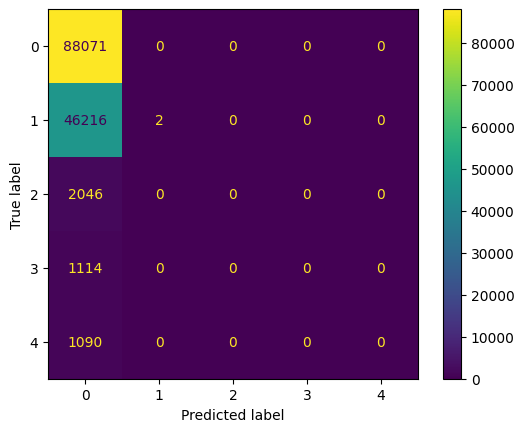

In [45]:
import random

#Identify the unique 'Total Length of Bwd Packets' values of all classes
unique_values = df['Total Length of Bwd Packets'].unique()

random.seed(42)

def SystematicShuffling(X, y, feature='Total Length of Bwd Packets'):
    # Ensure X and y are pandas DataFrames and Series
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=df.drop(columns=['Label']).columns)
    if isinstance(y, np.ndarray):
        y = pd.Series(y)

    X_copy = X.copy()
    y_copy = y.copy()

    # Loop through the dataset
    for idx in range(len(X)):
        X_copy.loc[idx, feature] = random.choice(unique_values)

    return X_copy, y_copy


X_evasive3, y_evasive3 = SystematicShuffling(X_test, y_test, feature='Total Length of Bwd Packets')

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,f1_score,recall_score

y_pred3_evasive = clf.predict(X_evasive3)
print("Accuracy:", accuracy_score(y_evasive3,y_pred3_evasive))

Perturb03=ConfusionMatrixDisplay.from_predictions(y_evasive3, y_pred3_evasive)
Perturb03.confusion_matrix

### Chaning Feature the 2nd Lowest-cardinality feature - Both Benign and Malicious Shuffle (Destination Port)

C:\Users\dyari\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


Accuracy: 0.6357343419542512


array([[88071,     0,     0,     0,     0],
       [46215,     3,     0,     0,     0],
       [ 2046,     0,     0,     0,     0],
       [ 1114,     0,     0,     0,     0],
       [ 1090,     0,     0,     0,     0]], dtype=int64)

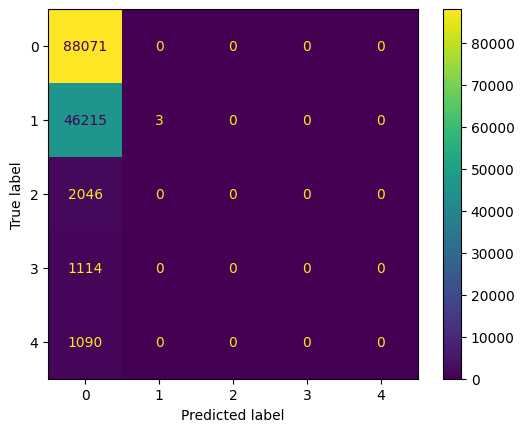

In [51]:
import random

#Identify the unique 'Destination Port' values of all classes
unique_values = df['Destination Port'].unique()

random.seed(42)

def SystematicShuffling(X, y, feature='Destination Port'):
    # Ensure X and y are pandas DataFrames and Series
    if isinstance(X, np.ndarray):
        X = pd.DataFrame(X, columns=df.drop(columns=['Label']).columns)
    if isinstance(y, np.ndarray):
        y = pd.Series(y)

    X_copy = X.copy()
    y_copy = y.copy()

    # Loop through the dataset
    for idx in range(len(X)):
        X_copy.loc[idx, feature] = random.choice(unique_values)

    return X_copy, y_copy


X_evasive3, y_evasive3 = SystematicShuffling(X_test, y_test, feature='Destination Port')

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,f1_score,recall_score

y_pred3_evasive = clf.predict(X_evasive3)
print("Accuracy:", accuracy_score(y_evasive3,y_pred3_evasive))

Perturb03=ConfusionMatrixDisplay.from_predictions(y_evasive3, y_pred3_evasive)
Perturb03.confusion_matrix